# Hoja de Trabajo Práctico Nº 2
## Ángulos de Euler, Gimbal Lock y Validación Simbólica/Numérica

**Asignatura:** Robótica — IMT-342

**Integrantes:**
- Mario Alberto Nina Gallo
- Roberth Ruiz


# 1. Ejercicio 1 — Deducción Simbólica y Extracción (Teórica)

El desarrollo del Ejercicio 1 se presenta mediante la evidencia manuscrita realizada para la práctica.


## 1.1 Evidencia manuscrita — Hoja 1

![Ejercicio 1 - Hoja 1](evidencias/ejercicio1_hoja_1.jpg)


## 1.2 Evidencia manuscrita — Hoja 2

![Ejercicio 1 - Hoja 2](evidencias/ejercicio1_hoja_2.jpg)


## 1.3 Evidencia manuscrita — Hoja 3

![Ejercicio 1 - Hoja 3](evidencias/ejercicio1_hoja_3.jpg)


# 2. Ejercicio 2 — Análisis del Gimbal Lock en SymPy

## 2.1 Definición simbólica de las variables

Se definen los ángulos de Euler ZYZ como variables simbólicas para construir y analizar la matriz de rotación de forma exacta.

In [1]:
import sympy as sp

phi, theta, psi = sp.symbols('phi theta psi', real=True)

## 2.2 Construcción de la matriz de rotación ZYZ

Para la secuencia de Euler ZYZ se utilizan las matrices de rotación alrededor de Z, Y y nuevamente Z. La matriz resultante se obtiene mediante:

$$
R_{ZYZ} = R_z(\phi)R_y(\theta)R_z(\psi)
$$

In [2]:
Rz_phi = sp.Matrix([
    [sp.cos(phi), -sp.sin(phi), 0],
    [sp.sin(phi),  sp.cos(phi), 0],
    [0,             0,           1]
])

Ry_theta = sp.Matrix([
    [sp.cos(theta), 0, sp.sin(theta)],
    [0,              1, 0],
    [-sp.sin(theta), 0, sp.cos(theta)]
])

Rz_psi = sp.Matrix([
    [sp.cos(psi), -sp.sin(psi), 0],
    [sp.sin(psi),  sp.cos(psi), 0],
    [0,             0,           1]
])

R_ZYZ = sp.simplify(Rz_phi * Ry_theta * Rz_psi)

sp.pprint(R_ZYZ)

⎡-sin(φ)⋅sin(ψ) + cos(φ)⋅cos(ψ)⋅cos(θ)  -sin(φ)⋅cos(ψ) - sin(ψ)⋅cos(φ)⋅cos(θ)  ↪
⎢                                                                              ↪
⎢sin(φ)⋅cos(ψ)⋅cos(θ) + sin(ψ)⋅cos(φ)   -sin(φ)⋅sin(ψ)⋅cos(θ) + cos(φ)⋅cos(ψ)  ↪
⎢                                                                              ↪
⎣           -sin(θ)⋅cos(ψ)                          sin(ψ)⋅sin(θ)              ↪

↪  sin(θ)⋅cos(φ)⎤
↪               ⎥
↪  sin(φ)⋅sin(θ)⎥
↪               ⎥
↪     cos(θ)    ⎦


## 2.3 Evaluación de la matriz en $\theta=0$

Para analizar el Gimbal Lock se evalúa la matriz cuando el ángulo intermedio cumple:

$$
\theta=0
$$


In [3]:
R_singular = sp.simplify(R_ZYZ.subs(theta, 0))

sp.pprint(R_singular)

⎡cos(φ + ψ)  -sin(φ + ψ)  0⎤
⎢                          ⎥
⎢sin(φ + ψ)  cos(φ + ψ)   0⎥
⎢                          ⎥
⎣    0            0       1⎦


## 2.4 Dependencia de $\phi+\psi$

Al evaluar la matriz para $\theta=0$, se observa que los ángulos $\phi$ y $\psi$ dejan de aparecer de forma independiente. La orientación depende únicamente de la suma:

$$
\phi+\psi
$$

Por lo tanto:

$$
R_{ZYZ}(\phi,0,\psi)=R_z(\phi+\psi)
$$

In [4]:
R_expected = sp.Matrix([
    [sp.cos(phi + psi), -sp.sin(phi + psi), 0],
    [sp.sin(phi + psi),  sp.cos(phi + psi), 0],
    [0,                  0,                  1]
])

print("¿R_ZYZ(phi,0,psi) = Rz(phi + psi)?")
print(sp.simplify(R_singular - R_expected) == sp.zeros(3))

¿R_ZYZ(phi,0,psi) = Rz(phi + psi)?
True


## 2.5 Dependencia lineal de las derivadas

Para demostrar el Gimbal Lock simbólicamente, se calculan las derivadas parciales de $R_{ZYZ}$ respecto de $\phi$ y $\psi$.

Luego se evalúan en:

$$
\theta = 0
$$

y se comprueba que ambas derivadas son iguales:

$$
\left.\frac{\partial R_{ZYZ}}{\partial \phi}\right|_{\theta=0}
=
\left.\frac{\partial R_{ZYZ}}{\partial \psi}\right|_{\theta=0}
$$

Esto demuestra que las variaciones de $\phi$ y $\psi$ producen el mismo efecto sobre la orientación, por lo que se pierde un grado de libertad independiente.

In [5]:
dR_dphi = R_ZYZ.diff(phi)
dR_dpsi = R_ZYZ.diff(psi)

dR_dphi_lock = sp.simplify(dR_dphi.subs(theta, 0))
dR_dpsi_lock = sp.simplify(dR_dpsi.subs(theta, 0))

sp.pprint(dR_dphi_lock)
sp.pprint(dR_dpsi_lock)

⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦
⎡-sin(φ + ψ)  -cos(φ + ψ)  0⎤
⎢                           ⎥
⎢cos(φ + ψ)   -sin(φ + ψ)  0⎥
⎢                           ⎥
⎣     0            0       0⎦


In [6]:
print(
    "¿Las derivadas son iguales en theta = 0?",
    sp.simplify(dR_dphi_lock - dR_dpsi_lock) == sp.zeros(3)
)

¿Las derivadas son iguales en theta = 0? True


## Conclusión del Ejercicio 2

Los resultados obtenidos muestran que, cuando $\theta=0$, la matriz $R_{ZYZ}$ depende únicamente de la suma $\phi+\psi$. Además, las derivadas parciales respecto de $\phi$ y $\psi$ son iguales en esta configuración.

Por lo tanto, $\phi$ y $\psi$ dejan de representar movimientos independientes. Se pierde un grado de libertad y aparece el **Gimbal Lock**.

## Ejercicio 3: Simulación del caso de estudio ABB IRB 120

Se considera una orientación de la muñeca del robot expresada mediante ángulos de Euler ZYZ:

$$
\phi = 45^\circ,\qquad
\theta = 0.0001^\circ,\qquad
\psi = 30^\circ
$$

La matriz de orientación se obtiene mediante:

$$
R_{ZYZ} = R_z(\phi)\,R_y(\theta)\,R_z(\psi)
$$

### Inciso 1: Evaluación numérica de $R_{ZYZ}$

Se evaluará la matriz de rotación utilizando NumPy.

In [7]:
import numpy as np

phi = np.deg2rad(45)
theta = np.deg2rad(0.0001)
psi = np.deg2rad(30)

print("phi =", phi)
print("theta =", theta)
print("psi =", psi)

phi = 0.7853981633974483
theta = 1.7453292519943296e-06
psi = 0.5235987755982988


In [8]:
Rz_phi = np.array([
    [np.cos(phi), -np.sin(phi), 0],
    [np.sin(phi),  np.cos(phi), 0],
    [0,            0,           1]
])

print("Rz(phi) =")
print(Rz_phi)

Rz(phi) =
[[ 0.70710678 -0.70710678  0.        ]
 [ 0.70710678  0.70710678  0.        ]
 [ 0.          0.          1.        ]]


In [9]:
Ry_theta = np.array([
    [ np.cos(theta), 0, np.sin(theta)],
    [ 0,             1, 0            ],
    [-np.sin(theta), 0, np.cos(theta)]
])

print("Ry(theta) =")
print(Ry_theta)

Ry(theta) =
[[ 1.00000000e+00  0.00000000e+00  1.74532925e-06]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-1.74532925e-06  0.00000000e+00  1.00000000e+00]]


In [10]:
Rz_psi = np.array([
    [np.cos(psi), -np.sin(psi), 0],
    [np.sin(psi),  np.cos(psi), 0],
    [0,            0,           1]
])

print("Rz(psi) =")
print(Rz_psi)

Rz(psi) =
[[ 0.8660254 -0.5        0.       ]
 [ 0.5        0.8660254  0.       ]
 [ 0.         0.         1.       ]]


In [11]:
R_zyz = Rz_phi @ Ry_theta @ Rz_psi

print("R_ZYZ =")
print(R_zyz)

R_ZYZ =
[[ 2.58819045e-01 -9.65925826e-01  1.23413415e-06]
 [ 9.65925826e-01  2.58819045e-01  1.23413415e-06]
 [-1.51149947e-06  8.72664626e-07  1.00000000e+00]]


La matriz obtenida es aproximadamente:

$$
R_{ZYZ} =
\begin{bmatrix}
0.258819 & -0.965926 & 1.234\times10^{-6}\\
0.965926 & 0.258819 & 1.234\times10^{-6}\\
-1.511\times10^{-6} & 8.727\times10^{-7} & 1
\end{bmatrix}
$$

Debido a que $\theta = 0.0001^\circ$ es muy cercano a cero, la matriz
$R_y(\theta)$ es cercana a la identidad. Por ello, la orientación resultante
es muy próxima a una rotación de $75^\circ$ alrededor del eje $Z$.

### Inciso 2: Recuperación de los ángulos

A partir de la matriz $R_{ZYZ}$ calculada anteriormente, se intentarán recuperar los ángulos de Euler $(\phi,\theta,\psi)$.

Se sigue el mismo **procedimiento de extracción** utilizado en el Ejercicio 1: identificar elementos $r_{ij}$ de la matriz y emplear la función $\operatorname{atan2}$. Sin embargo, las fórmulas concretas del Ejercicio 1 corresponden a la parametrización RPY,

$$
R_{RPY}=R_z(\gamma)R_y(\beta)R_x(\alpha),
$$

mientras que en este ejercicio se trabaja con la parametrización ZYZ,

$$
R_{ZYZ}=R_z(\phi)R_y(\theta)R_z(\psi).
$$

Por esta razón, **no se aplican directamente las ecuaciones de extracción de RPY**; se utiliza el mismo método, pero se obtienen las expresiones correspondientes a la estructura ZYZ.

Para una rotación ZYZ se tienen los elementos:

$$
r_{13}=\cos\phi\sin\theta,\qquad
r_{23}=\sin\phi\sin\theta
$$

$$
r_{31}=-\sin\theta\cos\psi,\qquad
r_{32}=\sin\theta\sin\psi,\qquad
r_{33}=\cos\theta
$$

A partir de ellos se obtienen las ecuaciones de extracción:

$$
\phi=\operatorname{atan2}(r_{23},r_{13})
$$

$$
\theta=
\operatorname{atan2}
\left(
\sqrt{r_{13}^2+r_{23}^2},
r_{33}
\right)
$$

$$
\psi=\operatorname{atan2}(r_{32},-r_{31})
$$


In [12]:
# Elementos necesarios de la matriz R_ZYZ
r13 = R_zyz[0, 2]
r23 = R_zyz[1, 2]
r31 = R_zyz[2, 0]
r32 = R_zyz[2, 1]
r33 = R_zyz[2, 2]

print("r13 =", r13)
print("r23 =", r23)
print("r31 =", r31)
print("r32 =", r32)
print("r33 =", r33)

r13 = 1.2341341494878087e-06
r23 = 1.2341341494878085e-06
r31 = -1.5114994701944144e-06
r32 = 8.726646259967217e-07
r33 = 0.9999999999984769


In [13]:
phi_calc = np.arctan2(r23, r13)

theta_calc = np.arctan2(
    np.sqrt(r13**2 + r23**2),
    r33
)

psi_calc = np.arctan2(r32, -r31)

In [14]:
phi_calc_deg = np.rad2deg(phi_calc)
theta_calc_deg = np.rad2deg(theta_calc)
psi_calc_deg = np.rad2deg(psi_calc)

print("phi calculado =", phi_calc_deg, "°")
print("theta calculado =", theta_calc_deg, "°")
print("psi calculado =", psi_calc_deg, "°")

phi calculado = 45.0 °
theta calculado = 0.00010000000000000002 °
psi calculado = 29.999999999999996 °


Los ángulos recuperados son aproximadamente:

$$
\phi=45^\circ,\qquad
\theta=0.0001^\circ,\qquad
\psi=30^\circ
$$

Estos valores coinciden prácticamente con los ángulos originales. Las pequeñas diferencias observadas en los decimales se deben a la representación numérica en punto flotante.

Por lo tanto, para $\theta=0.0001^\circ$ los ángulos todavía pueden recuperarse correctamente.

### Inciso 3: Análisis cerca de la singularidad

Se repite el cálculo anterior manteniendo:

$$
\phi=45^\circ,\qquad \psi=30^\circ
$$

pero utilizando un valor de $\theta$ mucho más cercano a cero:

$$
\theta=0.00000000001^\circ=10^{-11}\,^\circ
$$

El objetivo es observar cómo se comporta la extracción de los ángulos al acercarse a la singularidad $\theta=0$ y analizar el efecto de la precisión numérica.

Primero se realizará el cálculo utilizando directamente la precisión `float64` de NumPy. Después, de manera deliberada, se redondeará la matriz a 12 decimales para **simular una pérdida adicional de precisión** y observar qué ocurre cuando los términos muy pequeños dejan de conservarse.


In [15]:
theta_small = np.deg2rad(0.00000000001)

print("theta en grados =", 0.00000000001)
print("theta en radianes =", theta_small)

theta en grados = 1e-11
theta en radianes = 1.7453292519943293e-13


In [16]:
Ry_theta_small = np.array([
    [ np.cos(theta_small), 0, np.sin(theta_small)],
    [ 0,                   1, 0                  ],
    [-np.sin(theta_small), 0, np.cos(theta_small)]
])

print("Ry(theta_small) =")
print(Ry_theta_small)

Ry(theta_small) =
[[ 1.00000000e+00  0.00000000e+00  1.74532925e-13]
 [ 0.00000000e+00  1.00000000e+00  0.00000000e+00]
 [-1.74532925e-13  0.00000000e+00  1.00000000e+00]]


In [17]:
R_zyz_small = Rz_phi @ Ry_theta_small @ Rz_psi

print("R_ZYZ para theta = 1e-11 grados:")
print(R_zyz_small)

R_ZYZ para theta = 1e-11 grados:
[[ 2.58819045e-01 -9.65925826e-01  1.23413415e-13]
 [ 9.65925826e-01  2.58819045e-01  1.23413415e-13]
 [-1.51149947e-13  8.72664626e-14  1.00000000e+00]]


In [18]:
r13_small = R_zyz_small[0, 2]
r23_small = R_zyz_small[1, 2]
r31_small = R_zyz_small[2, 0]
r32_small = R_zyz_small[2, 1]
r33_small = R_zyz_small[2, 2]

print("r13 =", r13_small)
print("r23 =", r23_small)
print("r31 =", r31_small)
print("r32 =", r32_small)
print("r33 =", r33_small)

r13 = 1.234134149488435e-13
r23 = 1.2341341494884347e-13
r31 = -1.5114994701951814e-13
r32 = 8.726646259971645e-14
r33 = 1.0


In [19]:
phi_calc_small = np.arctan2(r23_small, r13_small)

theta_calc_small = np.arctan2(
    np.sqrt(r13_small**2 + r23_small**2),
    r33_small
)

psi_calc_small = np.arctan2(r32_small, -r31_small)

In [20]:
phi_calc_small_deg = np.rad2deg(phi_calc_small)
theta_calc_small_deg = np.rad2deg(theta_calc_small)
psi_calc_small_deg = np.rad2deg(psi_calc_small)

print("phi calculado =", phi_calc_small_deg, "°")
print("theta calculado =", theta_calc_small_deg, "°")
print("psi calculado =", psi_calc_small_deg, "°")

phi calculado = 44.99999999999999 °
theta calculado = 1e-11 °
psi calculado = 29.999999999999996 °


In [21]:
R_zyz_trunc = np.round(R_zyz_small, decimals=12)

print("Matriz después del truncamiento:")
print(R_zyz_trunc)

Matriz después del truncamiento:
[[ 0.25881905 -0.96592583  0.        ]
 [ 0.96592583  0.25881905  0.        ]
 [-0.          0.          1.        ]]


Para estudiar explícitamente la pérdida de información numérica, se redondea de forma deliberada la matriz a 12 decimales.

Este redondeo es una **simulación de truncamiento adicional**: no significa que NumPy `float64` haya convertido por sí solo estos términos en cero. En el cálculo anterior, `float64` todavía conservaba los valores del orden de $10^{-13}$ y permitía recuperar aproximadamente los ángulos originales.

Después del redondeo, los términos asociados a $\sin\theta$ se vuelven numéricamente cero. Se aplicarán nuevamente las ecuaciones de extracción para observar qué ocurre al llegar, por efecto del truncamiento simulado, a una representación numéricamente singular.


In [22]:
r13_trunc = R_zyz_trunc[0, 2]
r23_trunc = R_zyz_trunc[1, 2]
r31_trunc = R_zyz_trunc[2, 0]
r32_trunc = R_zyz_trunc[2, 1]
r33_trunc = R_zyz_trunc[2, 2]

print("r13 =", r13_trunc)
print("r23 =", r23_trunc)
print("r31 =", r31_trunc)
print("r32 =", r32_trunc)
print("r33 =", r33_trunc)

r13 = 0.0
r23 = 0.0
r31 = -0.0
r32 = 0.0
r33 = 1.0


In [23]:
phi_trunc = np.arctan2(r23_trunc, r13_trunc)

theta_trunc = np.arctan2(
    np.sqrt(r13_trunc**2 + r23_trunc**2),
    r33_trunc
)

psi_trunc = np.arctan2(r32_trunc, -r31_trunc)

print("phi calculado =", np.rad2deg(phi_trunc), "°")
print("theta calculado =", np.rad2deg(theta_trunc), "°")
print("psi calculado =", np.rad2deg(psi_trunc), "°")

phi calculado = 0.0 °
theta calculado = 0.0 °
psi calculado = 0.0 °


Al utilizar $\theta=10^{-11}\,^\circ$, los elementos de la matriz asociados
a $\sin\theta$ alcanzan valores del orden de $10^{-13}$.

Con la precisión `float64` utilizada por NumPy, las ecuaciones basadas en
`atan2` todavía permiten recuperar aproximadamente los valores originales:

$$
\phi\approx45^\circ,\qquad
\theta\approx10^{-11}\,^\circ,\qquad
\psi\approx30^\circ.
$$

Por tanto, en este caso **no se observa todavía una pérdida completa de los
ángulos usando `float64` sin modificar**.

A continuación se simuló una pérdida adicional de precisión redondeando la
matriz a 12 decimales. Con ese redondeo deliberado, los términos del orden de
$10^{-13}$ se convierten en cero.

En estas condiciones:

$$
r_{13}=r_{23}=r_{31}=r_{32}=0
$$

y las expresiones utilizadas para recuperar $\phi$ y $\psi$ contienen
$\operatorname{atan2}(0,0)$, por lo que estos ángulos ya no pueden
determinarse individualmente.

La matriz resultante conserva aproximadamente una rotación de $75^\circ$
alrededor de $Z$, correspondiente a:

$$
\phi+\psi=45^\circ+30^\circ=75^\circ.
$$

Esto evidencia la pérdida de información individual de $\phi$ y $\psi$
cuando la representación numérica alcanza la singularidad $\theta=0$.


### Inciso 4: Error de extracción angular cuando $\theta \to 0$

Se analizará el error en la recuperación del ángulo $\phi$ a medida que
$\theta$ se aproxima a cero.

El error de extracción se define como:

$$
e_\phi =
\left|
\phi_{\text{real}}-\phi_{\text{calculado}}
\right|
$$

Se mantendrán constantes:

$$
\phi_{\text{real}}=45^\circ,\qquad
\psi=30^\circ
$$

mientras que $\theta$ tomará valores progresivamente menores.

Para mantener el mismo experimento del inciso anterior, en cada iteración se
redondeará deliberadamente la matriz de rotación a 12 decimales. Este
redondeo se utiliza **sólo como una simulación controlada de pérdida de
precisión**. Por tanto, el valor de $\theta$ en el que aparezca el aumento del
error dependerá de ese criterio de redondeo y no constituye un umbral físico
propio del robot ni de la parametrización ZYZ.


In [24]:
theta_values_deg = np.logspace(-1, -14, 100)

print("Primer theta =", theta_values_deg[0], "°")
print("Último theta =", theta_values_deg[-1], "°")
print("Cantidad de valores =", len(theta_values_deg))

Primer theta = 0.1 °
Último theta = 1e-14 °
Cantidad de valores = 100


In [25]:
phi_real_deg = 45.0

phi_calculados = []
errores_phi = []

for theta_deg in theta_values_deg:
    theta_rad = np.deg2rad(theta_deg)

    Ry_actual = np.array([
        [ np.cos(theta_rad), 0, np.sin(theta_rad)],
        [ 0,                 1, 0                ],
        [-np.sin(theta_rad), 0, np.cos(theta_rad)]
    ])

    R_actual = Rz_phi @ Ry_actual @ Rz_psi

    R_actual_trunc = np.round(R_actual, decimals=12)

    r13_actual = R_actual_trunc[0, 2]
    r23_actual = R_actual_trunc[1, 2]

    phi_calc_actual = np.arctan2(r23_actual, r13_actual)
    phi_calc_actual_deg = np.rad2deg(phi_calc_actual)

    error_phi = abs(phi_real_deg - phi_calc_actual_deg)

    phi_calculados.append(phi_calc_actual_deg)
    errores_phi.append(error_phi)

In [26]:
print("Primer phi calculado =", phi_calculados[0], "°")
print("Primer error =", errores_phi[0], "°")

print("Último phi calculado =", phi_calculados[-1], "°")
print("Último error =", errores_phi[-1], "°")

Primer phi calculado = 45.0 °
Primer error = 0.0 °
Último phi calculado = 0.0 °
Último error = 45.0 °


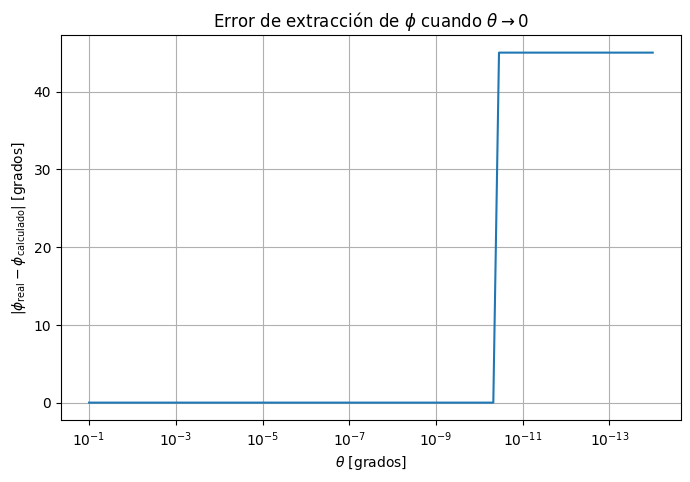

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.semilogx(theta_values_deg, errores_phi)

plt.xlabel(r"$\theta$ [grados]")
plt.ylabel(r"$|\phi_{\mathrm{real}}-\phi_{\mathrm{calculado}}|$ [grados]")
plt.title(r"Error de extracción de $\phi$ cuando $\theta \to 0$")

plt.grid(True)
plt.gca().invert_xaxis()

plt.show()

La gráfica muestra que, para valores de $\theta$ suficientemente alejados de
cero, el ángulo $\phi$ puede recuperarse correctamente y el error de extracción
permanece prácticamente nulo.

Sin embargo, a medida que $\theta$ se aproxima a cero, los elementos

$$
r_{13}=\cos\phi\sin\theta
\qquad\text{y}\qquad
r_{23}=\sin\phi\sin\theta
$$

también se aproximan a cero.

En este experimento se simuló de forma deliberada una pérdida adicional de
precisión mediante un redondeo de la matriz a 12 decimales. Cuando dichos
elementos se vuelven numéricamente iguales a cero, la ecuación

$$
\phi=\operatorname{atan2}(r_{23},r_{13})
$$

se reduce a:

$$
\operatorname{atan2}(0,0),
$$

por lo que ya no existe información suficiente para recuperar $\phi$ de forma
individual.

NumPy devuelve en este caso $\phi_{\mathrm{calculado}}=0^\circ$, produciendo:

$$
\left|
\phi_{\mathrm{real}}-\phi_{\mathrm{calculado}}
\right|
=
|45^\circ-0^\circ|
=
45^\circ.
$$

El salto observado en la gráfica evidencia la pérdida de información angular
cuando la representación numérica llega a la singularidad. **La posición del
salto depende del redondeo a 12 decimales empleado en este experimento**; no
debe interpretarse como un límite exacto de `float64` ni como un umbral físico
del ABB IRB 120.
